# Directional clustering — spherical k-means & von Mises–Fisher

Modern embeddings (CLIP, face, sentence, speaker) are usually **L2-normalized**, so every point
lives on the unit hypersphere `S^{d-1}` and **cosine — not Euclidean — geometry** is what carries
the cluster. betula-cluster has two directional heads that run on the CF-tree's `M ≪ N`
microclusters:

- **`method="spherical-kmeans"`** — hard assignment by maximal cosine, centers re-normalized to
  the sphere.
- **`method="vmf"`** — a soft **mixture of von Mises–Fisher** distributions: a true posterior for
  `predict_proba`, a per-cluster concentration `κ`, and **BIC auto-`k`** when `n_clusters=0`.

Both keep each leaf's weighted mean `μ_i`, so the cluster resultant `R_c = Σ n_i μ_i` stays
**exactly mergeable** — the BETULA property carries straight through to the sphere. Input is
**auto-L2-normalized** for these methods, so you can hand them raw (un-normalized) embeddings.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import adjusted_rand_score

import betula_cluster

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})


def vmf_blobs(n_per, dim, n_clusters, spread=0.3, seed=0):
    """Unit-norm points clustered around random directions on `S^{dim-1}`; returns (X, y, centers)."""
    rng = np.random.default_rng(seed)
    centers = rng.normal(size=(n_clusters, dim))
    centers /= np.linalg.norm(centers, axis=1, keepdims=True)
    xs, ys = [], []
    for c, ctr in enumerate(centers):
        pts = ctr + spread * rng.normal(size=(n_per, dim))
        pts /= np.linalg.norm(pts, axis=1, keepdims=True)
        xs.append(pts)
        ys += [c] * n_per
    return np.vstack(xs), np.array(ys), centers

## On the sphere (S²)

Four direction clusters on the 2-sphere. The vMF mixture recovers them from the angular structure
alone.

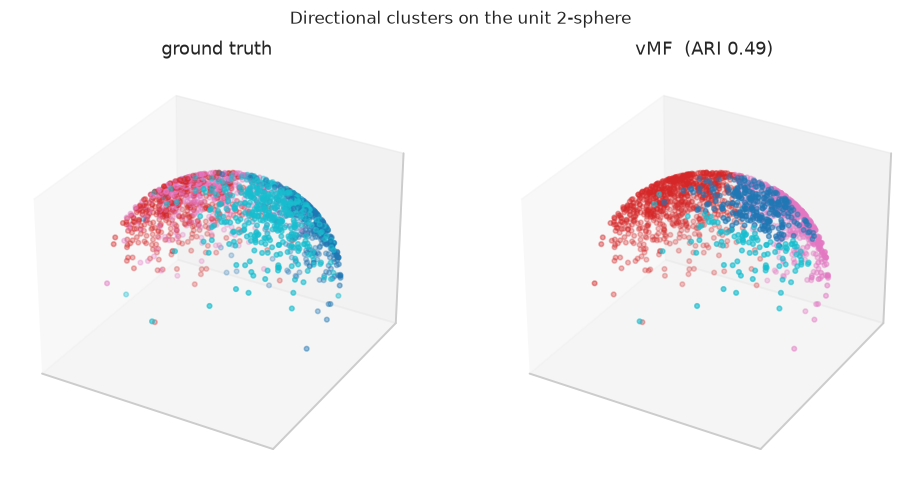

In [2]:
X3, y3, _ = vmf_blobs(400, 3, 4, spread=0.33, seed=1)
lab_vmf = betula_cluster.fit_predict(X3, n_clusters=4, method="vmf", threshold=0.08, max_leaves=300, seed=0)

fig = plt.figure(figsize=(9, 4.4))
for i, (lab, title) in enumerate(
    [(y3, "ground truth"), (lab_vmf, f"vMF  (ARI {adjusted_rand_score(y3, lab_vmf):.2f})")]
):
    ax = fig.add_subplot(1, 2, i + 1, projection="3d")
    ax.scatter(X3[:, 0], X3[:, 1], X3[:, 2], c=lab, cmap="tab10", s=9, alpha=0.8)
    ax.set(title=title, xticks=[], yticks=[], zticks=[])
fig.suptitle("Directional clusters on the unit 2-sphere", y=0.99)
fig.tight_layout()

## Why direction, not distance: 32-D embeddings with varying magnitude

Real embeddings are rarely unit-norm before you normalize them — their *magnitudes* vary while the
*direction* carries the semantic cluster. Here we scale each 32-D point by a random magnitude, so
**Euclidean** distance is dominated by `‖x‖` and plain k-means clusters by size. The directional
heads auto-normalize, so they still cluster by angle.

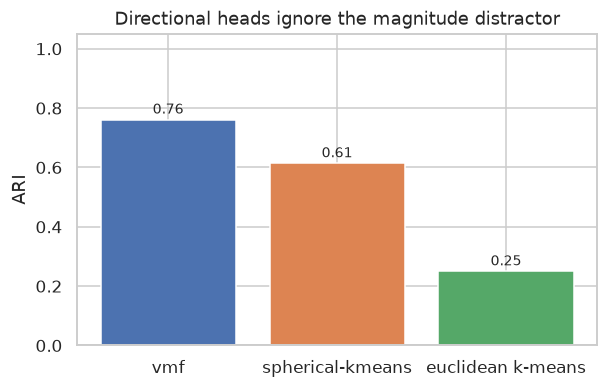

In [3]:
Xh, yh, _ = vmf_blobs(500, 32, 6, spread=0.3, seed=2)
mag = np.random.default_rng(7).uniform(0.2, 3.0, size=(len(Xh), 1))
Xh_scaled = Xh * mag  # direction still carries the cluster; magnitude is now a distractor

methods = {"vmf": "vmf", "spherical-kmeans": "spherical-kmeans", "euclidean k-means": "kmeans"}
fit = dict(n_clusters=6, threshold=0.08, max_leaves=400, seed=0)
aris = {
    name: adjusted_rand_score(yh, betula_cluster.fit_predict(Xh_scaled, method=m, **fit))
    for name, m in methods.items()
}

fig, ax = plt.subplots(figsize=(5.6, 3.6))
ax.bar(list(aris), list(aris.values()), color=sns.color_palette("deep", len(aris)))
ax.set(ylabel="ARI", ylim=(0, 1.05), title="Directional heads ignore the magnitude distractor")
for i, v in enumerate(aris.values()):
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center")
fig.tight_layout()

## Soft assignment & concentration `κ`

The vMF mixture returns a **calibrated posterior** (`predict_proba`, routed through each point's
microcluster) — unlike the centroid heuristic k-means falls back to. The per-point max posterior is
a confidence: tight, well-separated direction clusters assign with high confidence.

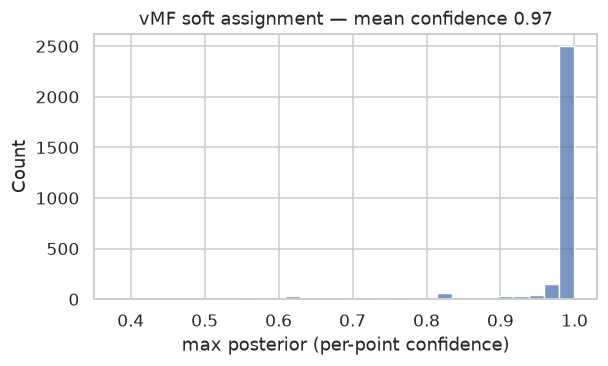

In [4]:
est = betula_cluster.Betula(method="vmf", n_clusters=6, threshold=0.08, max_leaves=400, seed=0).fit(Xh_scaled)
confidence = est.predict_proba(Xh_scaled).max(axis=1)

fig, ax = plt.subplots(figsize=(5.6, 3.4))
sns.histplot(confidence, bins=30, ax=ax)
ax.set(
    xlabel="max posterior (per-point confidence)",
    title=f"vMF soft assignment — mean confidence {confidence.mean():.2f}",
)
fig.tight_layout()

## Auto-`k` via BIC

With `n_clusters=0` the vMF mixture selects the component count itself (BIC over `k`), so you do
not have to know it in advance.

In [5]:
for true_k in (3, 5, 8):
    Xa, ya, _ = vmf_blobs(300, 32, true_k, spread=0.3, seed=20 + true_k)
    lab = betula_cluster.fit_predict(Xa, n_clusters=0, method="vmf", threshold=0.06, max_leaves=400, seed=0)
    print(f"true k = {true_k}  →  BIC picked {len(set(lab))}   (ARI {adjusted_rand_score(ya, lab):.2f})")

true k = 3  →  BIC picked 3   (ARI 0.92)


true k = 5  →  BIC picked 5   (ARI 0.81)


true k = 8  →  BIC picked 8   (ARI 0.82)


**Takeaways.** For L2-normalized (or magnitude-varying) embeddings, cluster by **direction**:
`method="vmf"` for a soft model with a posterior, concentration `κ`, and BIC auto-`k`, or
`method="spherical-kmeans"` for the fast hard version. Both auto-normalize the input and inherit
BETULA's bounded memory and exact-merge streaming. See the
[Usage guide](../docs/USAGE.md) and the directional section of [`docs/MATH.md`](../docs/MATH.md).